# Métodos de Diferencias Temporales (TD)

- `Joaquín Gayoso Filgueira - 205865`

En este notebook exploraremos métodos de diferencias temporales, una familia de técnicas en Reinforcement Learning (RL) que permiten aprender a través de la experiencia sin necesidad de conocer un modelo del entorno. En particular, abordaremos dos algoritmos fundamentales:

- **Sarsa (on-policy):** Un método de control en el que la política utilizada para seleccionar acciones es la misma que se evalúa y mejora.
- **Q-Learning (off-policy):** Un método que aprende la función de valor óptima de manera independiente de la política seguida, permitiendo una mayor flexibilidad en la exploración.

La implementación y el análisis se basan en el capítulo 6 del libro de Sutton y Barto, uno de los textos de referencia en el campo del aprendizaje por refuerzo.

## Objetivos

- **Implementación del algoritmo Q-Learning:** Desarrollar y ajustar el algoritmo para estimar la función de valor óptima.
- **Implementación del algoritmo Sarsa:** Desarrollar la versión on-policy para la estimación y mejora de la política.
- **Comparación de desempeño:** Evaluar y comparar el desempeño de ambos algoritmos en el entorno definido, midiendo el tiempo (o cantidad de episodios) necesario para alcanzar el objetivo de manera promedio.
- **Experimento en Cliff Walking:** Realizar el experimento clásico de Cliff Walking descrito en el libro para corroborar los conceptos y resultados presentados.


## Experimento: Cliff Walking

Reproducimos el ejemplo clásico de la **Figura 6.4** del libro
(*Sutton & Barto, §6.5*). El gridworld tiene una región de "acantilado"
en la fila inferior: caer ahí da recompensa $-100$ y resetea al inicio,
mientras que cualquier otro paso da $-1$.

Esperamos observar que:

- **Q-Learning** aprende la política óptima $\pi_*$ (camino pegado al borde),
  pero al seguir una política $\varepsilon$-greedy durante el entrenamiento
  cae al precipicio con frecuencia → recompensa promedio peor.
- **Sarsa** aprende un camino más conservador (alejado del borde) porque
  evalúa la política $\pi$ que realmente ejecuta, incluyendo la exploración.

Entorno: [`CliffWalking-v0`](https://gymnasium.farama.org/environments/toy_text/cliff_walking/).
Estado discreto $S \in \{0, \dots, 47\}$, $|\mathcal{A}| = 4$.


In [13]:
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
from gymnasium import spaces
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from Utils import plot_rewards, plot_epsilon, plot_rewards_comparison, random_argmax
%matplotlib inline

## Descripción del Ambiente: CliffWalking
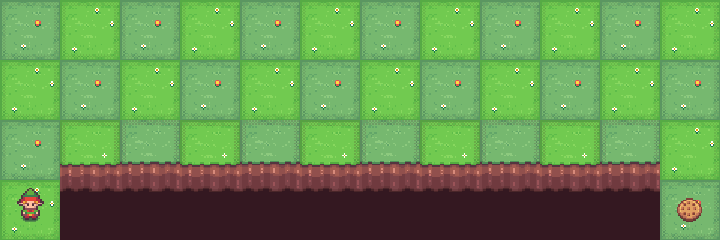

The game starts with the player at location [3, 0] of the 4x12 grid world with the goal located at [3, 11]. If the player reaches the goal the episode ends.

A cliff runs along [3, 1..10]. If the player moves to a cliff location it returns to the start location.

The player makes moves until they reach the goal.

Adapted from Example 6.6 (page 132) from Reinforcement Learning: An Introduction by Sutton and Barto [1].


**Espacio de Estados**

There are 3 x 12 + 1 possible states. The player cannot be at the cliff, nor at the goal as the latter results in the end of the episode. What remains are all the positions of the first 3 rows plus the bottom-left cell.

The observation is a value representing the player’s current position as current_row * ncols + current_col (where both the row and col start at 0).

For example, the starting position can be calculated as follows: 3 * 12 + 0 = 36.

The observation is returned as an int().

The episode starts with the player in state [36] (location [3, 0]).


**Acciones Disponibles**

The action shape is (1,) in the range {0, 3} indicating which direction to move the player.
- 0: Move up
- 1: Move right
- 2: Move down
- 3: Move left


**Función de Recompensa**

Each time step incurs -1 reward, unless the player stepped into the cliff, which incurs -100 reward.


In [14]:
def get_env(record_video=False, record_every=1, folder="./videos/"):
    """
    Crea el ambiente CliffWalking con grabación de video opcional.
    """
    render_mode = "rgb_array" if record_video else None
    env = gym.make("CliffWalking-v1", render_mode=render_mode)
    if record_video:
        env = RecordVideo(env,
                          video_folder=folder,
                          name_prefix="CliffWalker",
                          episode_trigger=lambda x: x % record_every == 0,
                          disable_logger=True)
    return env

In [15]:
env = get_env()
obs, info = env.reset()
print(f"Original observation: {obs}, Info {info}")
env.close()

Original observation: 36, Info {'prob': 1}


In [16]:
env = get_env(record_video=True, record_every=1, folder="./videos/random_actions")

obs, info = env.reset()
episode_over, i, rews = False, 0, 0
while not episode_over:
    i += 1
    action = env.action_space.sample()  # Random action
    obs, reward, terminated, truncated, _ = env.step(action)
    rews += reward
    episode_over = terminated or truncated

env.close()

In [17]:
print(f"Steps: {i}, Total reward: {rews}")
print(f"Obs: {obs}, Info: {info}")

Steps: 298, Total reward: -2278
Obs: 47, Info: {'prob': 1}


## Q-Learning
Q-Learning es un algoritmo de aprendizaje por refuerzo que busca aprender la función de valor óptima $Q^*(s, a)$ para cada par de estado-acción. A través de la exploración y explotación, el agente actualiza su tabla Q utilizando el siguiente algoritmo:

**Sutton & Barto, 2nd ed., §6.5 (p. 131).** Actualización off-policy:

$$
\begin{aligned}
&\textbf{Parámetros: } \alpha \in (0,1],\ \varepsilon \in (0,1],\ \gamma \in (0,1].\\
&\textbf{Inicializar: } Q(s,a)\ \text{arbitrario};\ Q(\text{terminal},\cdot) \leftarrow 0.\\
&\textbf{Loop por cada episodio:}\\
&\quad \text{Inicializar } S.\\
&\quad \textbf{mientras } S \text{ no sea terminal:}\\
&\quad\quad A \leftarrow \pi_\varepsilon(S)\ \text{con } \pi_\varepsilon\ \varepsilon\text{-greedy w.r.t. } Q.\\
&\quad\quad \text{Ejecutar } A,\ \text{observar } R,\ S'.\\
&\quad\quad Q(S,A) \leftarrow Q(S,A) + \alpha\bigl[R + \gamma \max_{a} Q(S',a) - Q(S,A)\bigr].\\
&\quad\quad S \leftarrow S'.
\end{aligned}
$$


Q Learning para Cliff Walking

In [18]:
def select_action(env, Q, pos, epsilon):
    """
    Politica e-greedy con desempate aleatorio.
        Con probabilidad epsilon explora: accion uniforme en A(s).
        Con probabilidad 1 - epsilon explota: argmax_a Q(s,a).

    Args:
        env     : ambiente Gymnasium (se usa env.action_space.sample()).
        Q       : tabla de valores, shape (NUMBER_STATES, n_actions).
        pos     : indice del estado.
        epsilon : probabilidad de explorar, en [0, 1].

    Returns:
        action (int): indice de la accion seleccionada en {0, ..., n_actions - 1}.
    """
    if np.random.rand() < epsilon:
        return env.action_space.sample()
    return random_argmax(Q[pos])

In [19]:
def q_learning(env, num_states, num_episodes=1000, alpha=.1, gamma=.99, epsilon_start=1.0, epsilon_decay=.995, epsilon_min=.05):
    """
    Q-learning (Sutton & Barto, sec. 6.5).

    Args:
        env          : ambiente discreto
        num_episodes : cantidad de episodios de entrenamiento. default=1000
        alpha        : tasa de aprendizaje, en (0, 1]. default=.1
        gamma        : factor de descuento, en (0, 1]. default=.99
        epsilon_start: epsilon inicial (mas exploracion). default=2.0
        epsilon_decay: factor multiplicativo aplicado por episodio. default=.995
        epsilon_min  : piso de epsilon (no decae por debajo). default=.05

    Returns:
        Q              (np.ndarray): tabla aprendida, shape (NUMBER_STATES, NUMBER_STATES, n_actions).
        episode_rewards(list[float]): retorno acumulado por episodio (largo num_episodes).
        epsilons       (list[float]): valor de epsilon usado en cada episodio.
    """
    Q = np.zeros((num_states, env.action_space.n), dtype=np.float32)
    episode_rewards, epsilons = [], []
    epsilon = epsilon_start
    pbar = tqdm(range(num_episodes), desc="QLearning for CliffWalking")
    for episode in pbar:
        G = 0
        pos, _ = env.reset()
        done = False
        while not done:
            action = select_action(env, Q, pos, epsilon)
            pos_next, reward, terminated, truncated, _ = env.step(action)
            
            G += reward
            td_target = reward + gamma*np.max(Q[pos_next])
            Q[pos, action] += alpha*(td_target - Q[pos, action])
            pos = pos_next
            done = terminated or truncated

        episode_rewards.append(G)
        epsilons.append(epsilon)
        epsilon = max(epsilon_min, epsilon*epsilon_decay)

        if (episode + 1) % 50 == 0:
            recent_rewards = np.mean(episode_rewards[-50:])
            pbar.set_postfix(rewards=recent_rewards, eps=epsilon)

    return Q, episode_rewards, epsilons

In [ ]:
CLIFF_EPISODES = 2000
CLIFF_STATES = 47

In [ ]:
env = get_env(record_video=True, record_every=int(CLIFF_EPISODES/10), folder="./videos/q_learning_training")

Q_ql, rewards_ql, epsilons_ql = q_learning(env=env,
                                           num_states=CLIFF_STATES,
                                           num_episodes=CLIFF_EPISODES)
env.close()

/home/jgayoso/anaconda3/envs/taller-ia/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /home/jgayoso/ort/tallerAI/labs/tallerAI_LAB4/CliffWalking/videos/q_learning_training folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
QLearning for CliffWalking: 100%|██████████| 2000/2000 [00:06<00:00, 326.02it/s, eps=0.05, rewards=-32.9]  


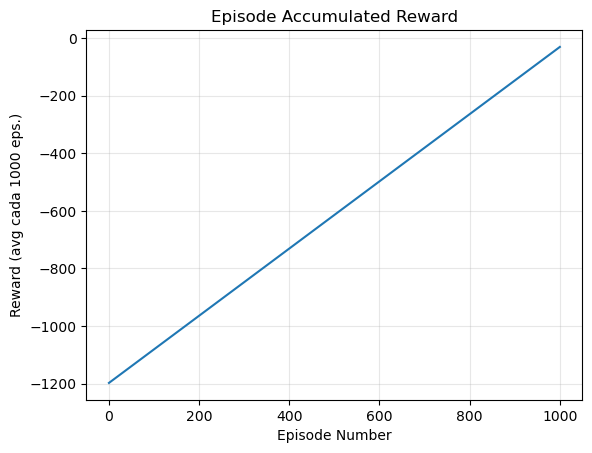

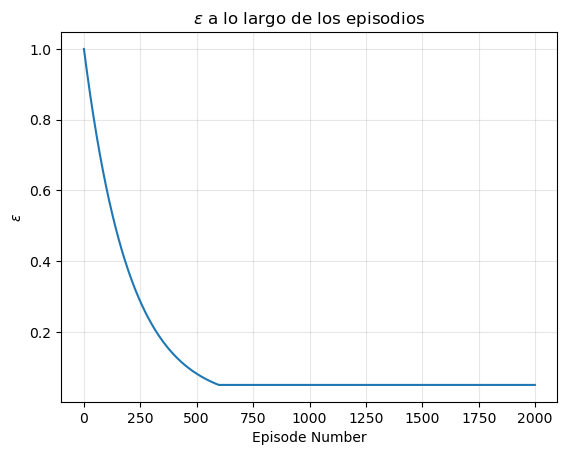

In [26]:
plot_rewards(rewards_ql)
plot_epsilon(epsilons_ql)

## SARSA
Sarsa es otro algoritmo de aprendizaje por refuerzo que, a diferencia de Q-Learning, es un método on-policy. Esto significa que el agente actualiza su tabla Q utilizando la acción que realmente toma en el entorno, lo que lo hace más sensible a la política actual. El algoritmo se basa en el siguiente algoritmo:

**Sutton & Barto, 2nd ed., §6.4 (p. 130).** Actualización on-policy:

$$
Q(S,A) \;\leftarrow\; Q(S,A) \;+\; \alpha\Bigl[\,R + \gamma\,Q(S',A') \;-\; Q(S,A)\Bigr]
$$

$$
\begin{aligned}
&\textbf{Sarsa (On-Policy TD Control)}\\[4pt]
&\textbf{Parámetros: } \alpha \in (0,1],\ \varepsilon > 0,\ \gamma \in (0,1].\\
&\textbf{Inicializar: } Q(s,a)\ \text{arbitrario};\ Q(\text{terminal},\cdot) \leftarrow 0.\\
&\textbf{Loop por cada episodio:}\\
&\quad \text{Inicializar } S;\ A \leftarrow \pi_\varepsilon(S).\\
&\quad \textbf{mientras } S \text{ no sea terminal:}\\
&\quad\quad \text{Ejecutar } A,\ \text{observar } R,\ S'.\\
&\quad\quad A' \leftarrow \pi_\varepsilon(S').\\
&\quad\quad Q(S,A) \leftarrow Q(S,A) + \alpha\bigl[R + \gamma\,Q(S',A') - Q(S,A)\bigr].\\
&\quad\quad S \leftarrow S',\ A \leftarrow A'.
\end{aligned}
$$

> **Diferencia clave con Q-Learning.** El target usa $Q(S', A')$ con $A' \sim \pi_\varepsilon$
> en lugar de $\max_a Q(S', a)$. Por eso Sarsa **evalúa la política que efectivamente
> sigue** (incluyendo la exploración), mientras que Q-Learning aprende la política
> greedy óptima $\pi_*$ independientemente de la política de comportamiento.


SARSA usa la misma politica que usa para recorrer que va actualizando mientras va aprendiendo.

In [27]:
def sarsa(env, num_states, num_episodes=1000, alpha=.1, gamma=.99, epsilon_start=1.0, epsilon_decay=0.995, epsilon_min=.05):
    """
    Sarsa on-policy (Sutton & Barto, sec. 6.4).

    Args:
        env          : ambiente discretizado.
        num_episodes : cantidad de episodios de entrenamiento.
        alpha        : tasa de aprendizaje, en (0, 1].
        gamma        : factor de descuento, en (0, 1].
        epsilon_*    : exploracion con decaimiento exponencial.

    Returns:
        Q              (np.ndarray): tabla aprendida, shape (NUMBER_STATES, NUMBER_STATES, n_actions).
        episode_rewards(list[float]): retorno acumulado por episodio.
        epsilons       (list[float]): valor de epsilon usado en cada episodio.
    """
    Q = np.zeros((num_states, env.action_space.n), dtype=np.float32)
    episode_rewards, epsilons = [], []
    epsilon = epsilon_start
    pbar = tqdm(range(num_episodes), desc="SARSA")
    for episode in pbar:
        G = 0
        pos, _ = env.reset()
        action = select_action(env, Q, pos, epsilon)
        done = False
        while not done:
            pos_next,reward, terminated, truncated, _ = env.step(action)
            G += reward
            action_next = select_action(env, Q, pos_next, epsilon)
            td_target = reward + gamma*Q[pos_next, action_next]
            Q[pos, action] += alpha*(td_target - Q[pos,action])
            pos = pos_next
            action = action_next
            done = terminated or truncated

        episode_rewards.append(G)
        epsilons.append(epsilon)
        epsilon = max(epsilon_min, epsilon*epsilon_decay)

        if (episode + 1) % 50 == 0:
            recent_rewards = np.mean(episode_rewards[-50:])
            pbar.set_postfix(rewards=recent_rewards, eps=epsilon)

    return Q, episode_rewards, epsilons

In [ ]:
env = get_env(record_video=True, record_every=int(CLIFF_EPISODES/10), folder="./videos/sarsa_training")

Q_sarsa, rewards_sarsa, epsilons_sarsa = sarsa(env, num_states=CLIFF_STATES, num_episodes=CLIFF_EPISODES)
env.close()

SARSA: 100%|██████████| 2000/2000 [00:18<00:00, 107.61it/s, eps=0.05, rewards=-18]   


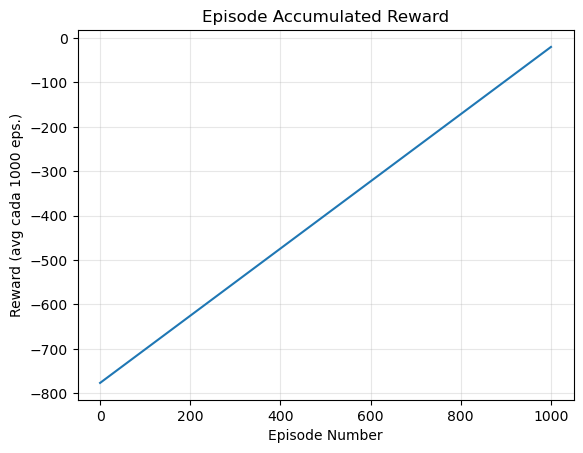

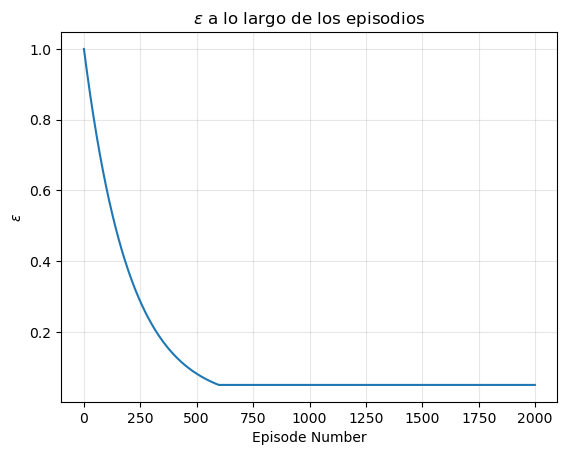

In [29]:
plot_rewards(rewards_sarsa)
plot_epsilon(epsilons_sarsa)

In [30]:
env = get_env(record_video=True, record_every=1, folder="./videos/sarsa_test")

for episode_num in range(5):
    pos, info = env.reset()
    episode_over = False
    while not episode_over:
        action = np.argmax(Q_sarsa[pos])  # Exploit
        pos, reward, terminated, truncated, info = env.step(action)
        episode_over = terminated or truncated

env.close()

### Comparación Q-Learning vs Sarsa en MountainCarCliffWalk

Ambas curvas suavizadas con media móvil sobre el mismo eje:


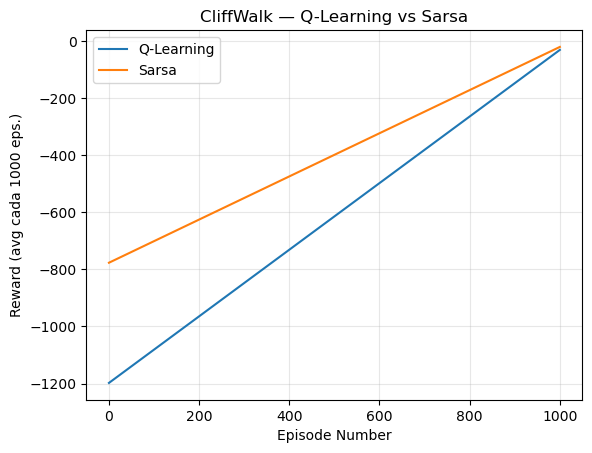

In [31]:
plot_rewards_comparison([rewards_ql, rewards_sarsa],
                        labels=["Q-Learning", "Sarsa"],
                        title="CliffWalk — Q-Learning vs Sarsa")

## Tareas

1. Implementar tanto el algoritmo de **Q-Learning** como el de **Sarsa** para estimar $Q^*$ en MountainCar (sección anterior).
2. Implementar el experimento de **Cliff Walking** (Sutton & Barto §6.5, Fig. 6.4) para comparar ambos algoritmos. Analizar y discutir los resultados: identificar cuál de los dos algoritmos tiende a *caminar por el borde* (más arriesgado) y cuál es más cauteloso, justificando la diferencia a partir del target de la actualización TD. Usar [CliffWalking](https://gymnasium.farama.org/environments/toy_text/cliff_walking/).
3. *(Opcional)* Resolver FrozenLake-v1 con is_slippery=True con ambos algoritmos.